## Informações de Contato

Email: 1666264@pucminas.edu.br

Nome: Matheus Lopes Lourenço

# Link da Base
https://www.kaggle.com/code/ybifoundation/logistic-regression

# Introdução
O objetivo é construir um modelo de Regressão Logística para prever a presença de diabetes em pacientes a partir de características clínicas. Esse tipo de modelo permite estimar a probabilidade de um indivíduo possuir diabetes e identificar quais fatores exercem maior influência sobre o diagnóstico.

# Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Análise Descritiva

In [32]:
df = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Diabetes.csv')

In [33]:
df.head(5)

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Distribuição dos Indicadores

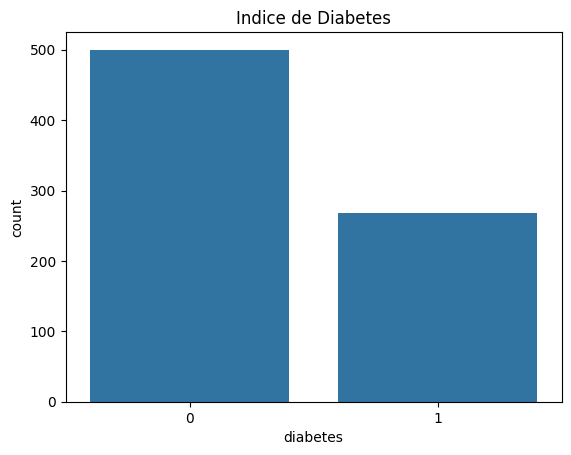

In [34]:
# Visualização da Varíavel Dependente (Target) - 0 = Não tem diabetes, 1 = Tem diabetes
sns.countplot(x='diabetes', data=df)
plt.title("Indice de Diabetes")
plt.show()

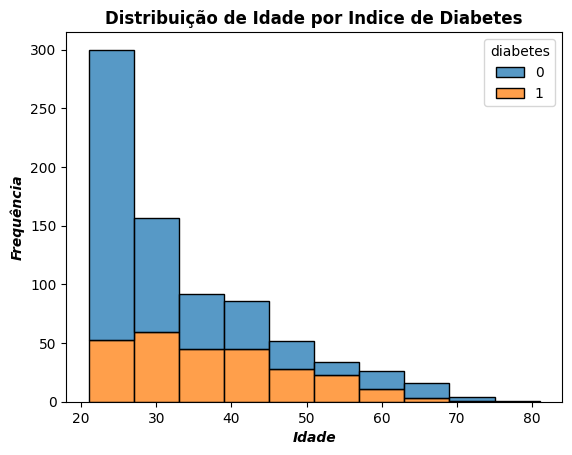

In [35]:
# Distribuição de Idade por Tem Diabetes ou Não
sns.histplot(data=df, x='age', hue='diabetes', multiple='stack', bins=10)
plt.title("Distribuição de Idade por Indice de Diabetes", fontweight='bold')
plt.xlabel("Idade", fontstyle='italic', fontweight='bold')
plt.ylabel("Frequência", fontstyle='italic', fontweight='bold')
plt.show()

## Observações da Base

In [36]:
df.describe(include='all')

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [37]:
# Verificando valores Duplicados
df.duplicated().sum()

np.int64(0)

In [38]:
# Removendo valores duplicados
df = df.drop_duplicates()

In [39]:
# Verificando valores nulos
df.isnull().sum()

pregnancies    0
glucose        0
diastolic      0
triceps        0
insulin        0
bmi            0
dpf            0
age            0
diabetes       0
dtype: int64

In [40]:
df = df.fillna(0) # Preenche valores ausentes com 0 (Caso tenha algum)

## Gráfico de Correlação

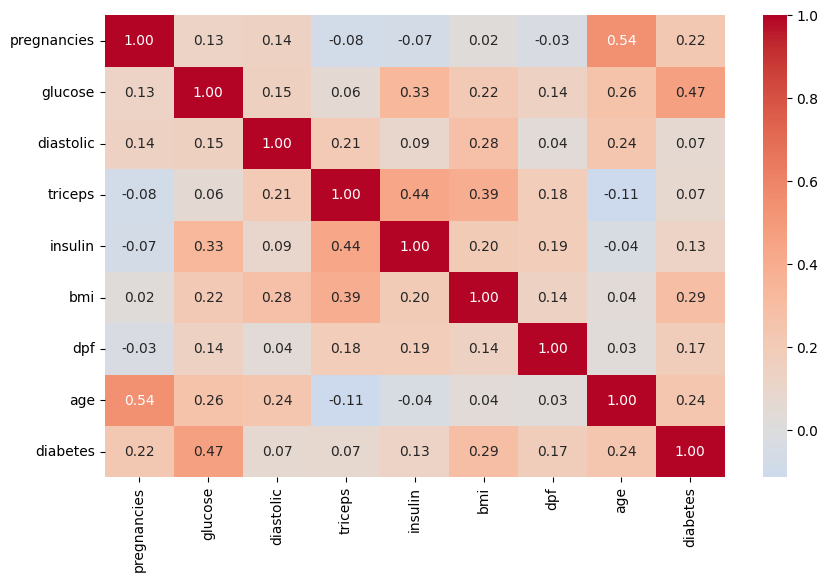

In [41]:
# Gráfico de Correlação das Variáveis
plt.figure(figsize=(10,6))
#sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
sns.heatmap(df.corr(),annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.show()

Podemos obeservar que a variável target, "diabetes", possui uma correlação muito forte com as seguintes variáveis:
*   glucose
*   bmi
*   age
*   dpf
*   pregnancies

# Modelo de Regressão Lógistica

In [42]:
# Criando Modelo de Regressão usando todas as variáveis
Y = df['diabetes'] # Variavel Dependente target
X = df[['pregnancies', 'glucose', 'diastolic', 'triceps', 'insulin', 'bmi','dpf', 'age']]

X = pd.get_dummies(X, dtype=int)
X = sm.add_constant(X) # Adiciona uma constante 

In [43]:
# Criação do Modelo de Regressão Logística
modelo = sm.Logit(Y, X)
resultado = modelo.fit()

print(resultado.summary())

Optimization terminated successfully.
         Current function value: 0.470993
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                  768
Model:                          Logit   Df Residuals:                      759
Method:                           MLE   Df Model:                            8
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.2718
Time:                        20:19:22   Log-Likelihood:                -361.72
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 9.652e-54
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -8.4047      0.717    -11.728      0.000      -9.809      -7.000
pregnancies     0.1232    

Foi visto 768 observações.

E o algoritmo convergiu, indicando que encontrou uma solução estável.

O Pseudo R² = 0,2718 indica que o modelo explica aproximadamente 27,18% da variação da ocorrência de diabetes. Diferentemente do R² da regressão linear, o Pseudo R² costuma apresentar valores menores e um resultado em torno de 0,27 pode ser considerado razoável.

O LLR p-value = 9,652 × 10⁻⁵⁴ é  menor que 0,05, indicando que o modelo como um todo é estatisticamente significativo. Ou seja, pelo menos uma das variáveis independentes contribui para explicar a ocorrência de diabetes.

P>|z| em cada variável:

Variável	p-valor	Significativa?

*   pregnancies	0.000	Sim
*   glucose	0.000	Sim
*   diastolic	0.011	Sim
*   triceps	0.929	Não
*   insulin	0.186	Não
*   bmi	0.000	Sim
*   dpf	0.002	Sim
*   age	0.111	Não

A regressão logística demonstrou significância estatística global (LLR p-value < 0,001), indicando que o conjunto de variáveis independentes é capaz de explicar a ocorrência de diabetes. 

O Pseudo R² de 0,2718 sugere um poder explicativo moderado. Entre as variáveis analisadas, número de gestações, glicose, pressão arterial diastólica, IMC e histórico familiar (DPF) apresentaram associação estatisticamente significativa com a ocorrência de diabetes (p < 0,05). 

Em contrapartida, espessura da dobra cutânea do tríceps, nível de insulina e idade não apresentaram significância estatística no modelo.

## Multicolinearidade

In [44]:
# Verificando a Multicolinearidade das Variáveis Independentes (VIF - Variance Inflation Factor)
vif = pd.DataFrame()
vif["Variável"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Variável,VIF
0,const,35.039974
1,pregnancies,1.430872
2,glucose,1.298961
3,diastolic,1.181863
4,triceps,1.507432
5,insulin,1.427536
6,bmi,1.297450
7,dpf,1.067090
8,age,1.588368


## Criação do Modelo de Teste e Treino

In [45]:
# Variável dependente (target)
y = df['diabetes']

# Variáveis independentes (features)
X = df[['pregnancies', 'glucose', 'diastolic', 'triceps','insulin', 'bmi', 'dpf', 'age']]

# Divisão dos dados
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantém a proporção das classes
)

# Padronização dos dados
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [47]:
# Previsão do Modelo com base nos dados de teste
pred = modelo.predict(X_test)

## Avaliando o Modelo

In [ ]:
acc = accuracy_score(y_test, pred)
print(f"Acurácia: {acc:.2%}")

Acurácia: 71.43%


## Matriz de Confusão para avaliar o modelo

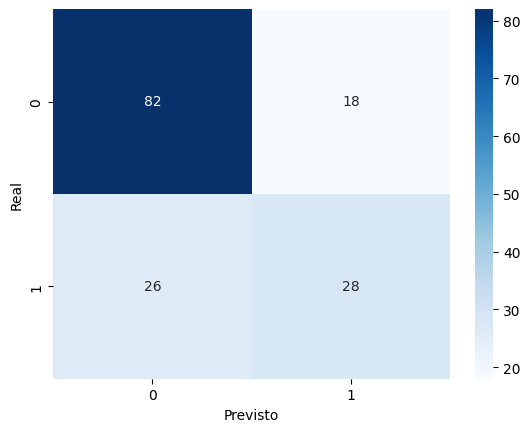

In [ ]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Relatório de Classificação Para Avaliar o Desempenho

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [ ]:
# Pipeline com padronização + regressão logística
modelo = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Validação cruzada
scores = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(f'Scores: {scores}')
print(f'Média dos Scores: {scores.mean():.2%}')

Scores: [0.77272727 0.74675325 0.75324675 0.81699346 0.76470588]
Média dos Scores: 77.09%


## Treino do Modelo

In [52]:
# Treina o modelo
modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


## Curva ROC

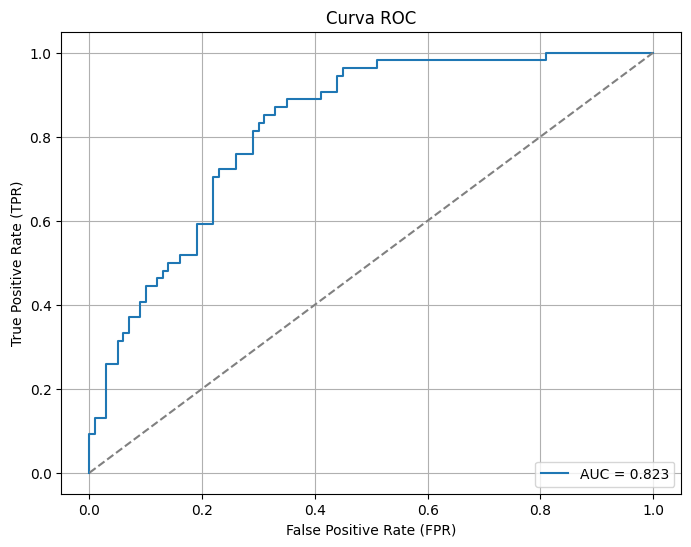

In [53]:
# Probabilidade da classe positiva (1) para o conjunto de teste
prob = modelo.predict_proba(X_test)[:, 1]

# AUC
auc = roc_auc_score(y_test, prob)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Resultados

In [54]:
print(resultado.summary()) 
# Relatório do Modelo de Regressão Logística, incluindo os coeficientes, erros padrão, valores p e outras métricas estatísticas importantes para avaliar 
# a significancia das variáveis independentes no modelo

                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                  768
Model:                          Logit   Df Residuals:                      759
Method:                           MLE   Df Model:                            8
Date:                Thu, 09 Jul 2026   Pseudo R-squ.:                  0.2718
Time:                        20:19:23   Log-Likelihood:                -361.72
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 9.652e-54
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -8.4047      0.717    -11.728      0.000      -9.809      -7.000
pregnancies     0.1232      0.032      3.840      0.000       0.060       0.186
glucose         0.0352      0.004      9.481    

Foi visto 768 observações.

E o algoritmo convergiu, indicando que encontrou uma solução estável.

O Pseudo R² = 0,2718 indica que o modelo explica aproximadamente 27,18% da variação da ocorrência de diabetes. Diferentemente do R² da regressão linear, o Pseudo R² costuma apresentar valores menores e um resultado em torno de 0,27 pode ser considerado razoável.

O LLR p-value = 9,652 × 10⁻⁵⁴ é  menor que 0,05, indicando que o modelo como um todo é estatisticamente significativo. Ou seja, pelo menos uma das variáveis independentes contribui para explicar a ocorrência de diabetes.

P>|z| em cada variável:

Variável	p-valor	Significativa?

*   pregnancies	0.000	Sim
*   glucose	0.000	Sim
*   diastolic	0.011	Sim
*   triceps	0.929	Não
*   insulin	0.186	Não
*   bmi	0.000	Sim
*   dpf	0.002	Sim
*   age	0.111	Não

A regressão logística demonstrou significância estatística global (LLR p-value < 0,001), indicando que o conjunto de variáveis independentes é capaz de explicar a ocorrência de diabetes. 

O Pseudo R² de 0,2718 sugere um poder explicativo moderado. Entre as variáveis analisadas, número de gestações, glicose, pressão arterial diastólica, IMC e histórico familiar (DPF) apresentaram associação estatisticamente significativa com a ocorrência de diabetes (p < 0,05). 

Em contrapartida, espessura da dobra cutânea do tríceps, nível de insulina e idade não apresentaram significância estatística no modelo.

## Cálculo de Odds

In [55]:
# Cálculo das Odds (Razões de Chance) das variáveis target / independentes, representando a mudança na probabilidade de ocorrência do evento para 
# cada unidade de aumento na variável independente, mantendo as outras variáveis constantes.
odds = np.exp(resultado.params)
odds

const          0.000224
pregnancies    1.131091
glucose        1.035789
diastolic      0.986792
triceps        1.000619
insulin        0.998809
bmi            1.093847
dpf            2.573276
age            1.014980
dtype: float64

Interpretação geral
*   Valores de OR > 1 indicam aumento das chances de ocorrência de diabetes.
*   Valores de OR < 1 indicam redução das chances.
Quanto mais distante de 1, maior o impacto da variável.

No seu modelo, as variáveis com maior impacto e que também apresentaram significância estatística (p < 0,05) foram:

*   DPF (OR = 2,57): maior efeito relativo sobre as chances de diabetes.
*   BMI (OR = 1,09): aumento do IMC eleva significativamente as chances de diabetes.
*   Pregnancies (OR = 1,13): mais gestações estão associadas a maior chance de diabetes.
*   Glucose (OR = 1,04): níveis mais altos de glicose aumentam significativamente as chances de diabetes.

Já triceps, insulin e age, apesar de apresentarem odds ratios próximos de 1, não foram estatisticamente significativos (p > 0,05), indicando que, neste modelo, não há evidências suficientes de que contribuam de forma independente para explicar a ocorrência de diabetes.

In [56]:
# Intervalo de Confiança das Odds, representando a faixa de valores plausíveis para as odds, com base na variabilidade dos dados e no nível de confiança escolhido
ic = np.exp(resultado.conf_int())
ic.columns = ['Limite Inferior','Limite Superior']
ic

,Limite Inferior,Limite Superior
const,0.000055,0.000912
pregnancies,1.062167,1.204486
glucose,1.028287,1.043346
diastolic,0.976722,0.996967
triceps,0.987179,1.014242
insulin,0.997046,1.000575
bmi,1.061974,1.126677
dpf,1.431698,4.625100
age,0.996579,1.033721


In [57]:
# Tabela de Odds Ratio, incluindo os coeficientes, odds ratio e valores p para cada variável independente (target), permitindo avaliar 
# a força e a significancia das variáveis no modelo de regressão
odds_ratio = pd.DataFrame({
    'Coeficiente': resultado.params,
    'Odds Ratio': np.exp(resultado.params),
    'p-valor': resultado.pvalues
})

odds_ratio

,Coeficiente,Odds Ratio,p-valor
const,-8.404696,0.000224,9.161475e-32
pregnancies,0.123182,1.131091,1.229642e-04
glucose,0.035164,1.035789,2.509132e-21
diastolic,-0.013296,0.986792,1.107208e-02
triceps,0.000619,1.000619,9.285152e-01
insulin,-0.001192,0.998809,1.860652e-01
bmi,0.089701,1.093847,2.758957e-09
dpf,0.945180,2.573276,1.579980e-03
age,0.014869,1.014980,1.111920e-01


## Representação Gráfica

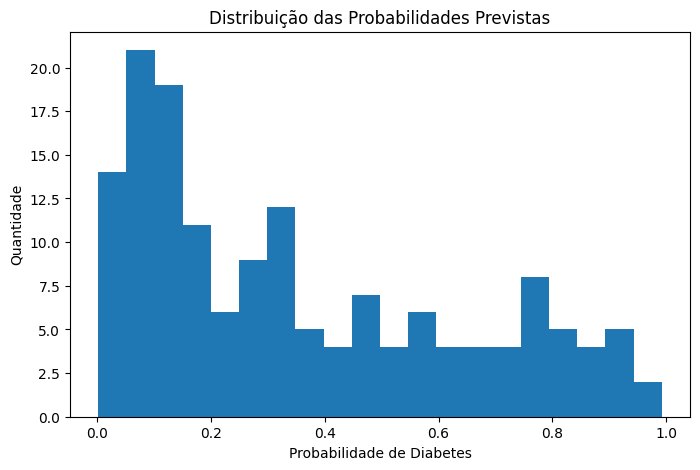

In [58]:
pred_prob = modelo.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,5))
plt.hist(pred_prob, bins=20)
plt.xlabel("Probabilidade de Diabetes")
plt.ylabel("Quantidade")
plt.title("Distribuição das Probabilidades Previstas")
plt.show()

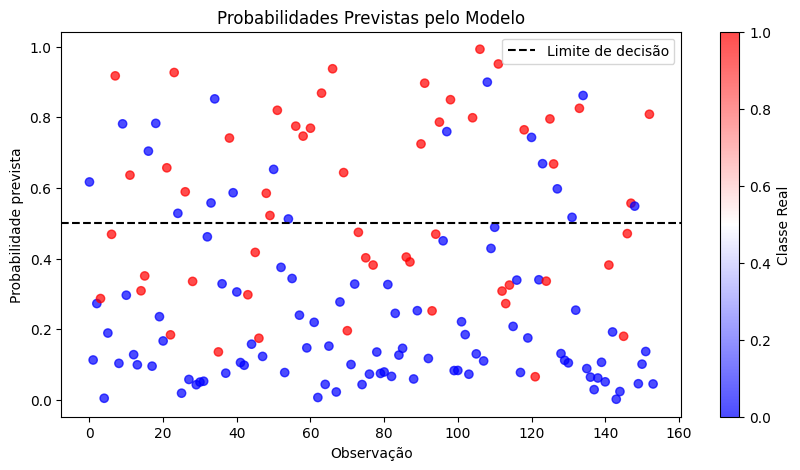

In [59]:
pred_prob = modelo.predict_proba(X_test)[:,1]

plt.figure(figsize=(10,5))
plt.scatter(
    range(len(pred_prob)),
    pred_prob,
    c=y_test,
    cmap='bwr',
    alpha=0.7
)

plt.axhline(0.5, color='black', linestyle='--', label='Limite de decisão')
plt.xlabel("Observação")
plt.ylabel("Probabilidade prevista")
plt.title("Probabilidades Previstas pelo Modelo")
plt.colorbar(label='Classe Real')
plt.legend()
plt.show()

Cada ponto representa um cliente, onde o eixo Y mostra a probabilidade prevista de compra. 

* Linha em 0,5 é o limite de decisão
* Cor indica a classe real (0 ou 1), facilitando identificar acertos e erros.

# Conclusão
O modelo de Regressão Logística apresentou desempenho satisfatório para a classificação de pacientes com diabetes. As variáveis glicose, IMC e histórico familiar mostraram maior influência sobre a probabilidade de ocorrência da doença. Os resultados indicam que a regressão logística é uma ferramenta adequada para problemas de classificação binária, além de permitir interpretar facilmente o efeito de cada variável por meio das razões de chances (Odds Ratio).

Lembrando que as variáveis com maior impacto e que também apresentaram significância estatística (p < 0,05) foram:

*   DPF (OR = 2,57): maior efeito relativo sobre as chances de diabetes.
*   BMI (OR = 1,09): aumento do IMC eleva significativamente as chances de diabetes.
*   Pregnancies (OR = 1,13): mais gestações estão associadas a maior chance de diabetes.
*   Glucose (OR = 1,04): níveis mais altos de glicose aumentam significativamente as chances de diabetes.

Segue uma versão mais fluida e conclusiva:

O modelo foi ajustado em 768 observações e apresentou convergência, indicando que o algoritmo encontrou uma solução estável para a estimação dos parâmetros. O R² de 0,2718 mostra que o modelo explica aproximadamente 27,18% da variação na ocorrência de diabetes, valor considerado razoável para regressão logística, em que essa métrica tende a ser inferior ao R² da regressão linear. Além disso, o LLR p-value de 9,652 × 10⁻⁵⁴, muito inferior ao nível de significância de 5%, demonstra que o modelo é estatisticamente significativo como um todo, evidenciando que pelo menos uma das variáveis independentes contribui significativamente para explicar a probabilidade de ocorrência de diabetes.
